# Representing geographic data as networks

Contents:

- Basic concepts: nodes, edges, node/edge attributes, topology, connectivity, directionality, what Python tools are out there that can be used?
- How to create a simple graph from scratch
- How to create a graph from a file representing streets
- How to create a routable graph from OpenStreetMap
- Other uses of graphs - morphology, spatial weights, etc.
- Saving graphs to disk

## Basic concepts

As we briefly introduced in Chapter 5.2, networks are data structures that consists of nodes that are connected to other nodes via edges which ultimately construct a network (or a graph as it is referred in graph theory). As networks are widely used in various domains, the names used for these basic elements of a network can sometime vary. To clarify some of the ambiguity related to these terms, we list commonly used terms related to spatial networks below:

- `Network` equals to `graph` (term used in graph theory)
- `Node` sometimes equals to `vertex` (term used in graph theory)
- `Edge` (used in graph theory) equals to `line` or `link`, and a `directed edge` can be called as an `arc` in graph theory.

In Python, most of the network analysis related libraries (e.g. `networkx`, `igraph`, `graphtool`) use the terminology derived from the graph theory, i.e. most of the libraries use constructs like `Graph`, `Edge` and `Vertex`. However, `networkx` library which we will mostly cover in this book differs partially as they use a construct `Node` instead of `Vertex`. This makes sense as in GIS there is a difference between these two: A `node` is specific to a point at which a line ends or connects to another line, whereas `vertices` can be in between the `nodes` as intermediate points along the geometry which is typical e.g. when representing road networks. Thus, every `node` of a `graph` can be considered as a `vertex` but not all `vertices` are `nodes`. 




## Creating a simple graph from scratch

### Undirected graph

In this first example, we will construct a simple graph using the `networkx` library and its `nx.Graph()` construct that allows you to create an undirected graph with nodes and edges. 

In [122]:
import networkx as nx

G = nx.Graph()
G

In [123]:
G.graph["name"] = "my first graph"
G

In [124]:
G.graph

{'name': 'my first graph'}

In [125]:
a_coords = (0,5)
b_coords = (5,5)
c_coords = (0,0)
d_coords = (5,0)
e_coords = (10,0)

G.add_node("a", coords=a_coords)
G.add_node("b", coords=b_coords)
G.add_node("c", coords=c_coords)
G.add_node("d", coords=d_coords)
G.add_node("e", coords=e_coords)

In [126]:
G.nodes

NodeView(('a', 'b', 'c', 'd', 'e'))

In [127]:
G.nodes.data()

NodeDataView({'a': {'coords': (0, 5)}, 'b': {'coords': (5, 5)}, 'c': {'coords': (0, 0)}, 'd': {'coords': (5, 0)}, 'e': {'coords': (10, 0)}})

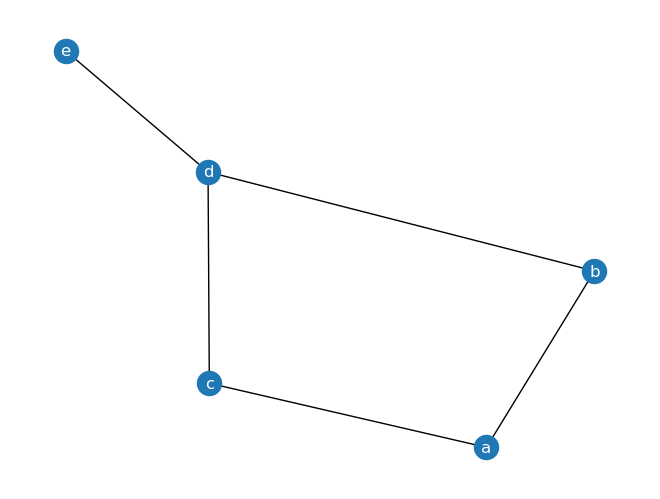

In [139]:
nx.draw(G, with_labels=True, font_color="white")

In [130]:
positions = {node: attrs["coords"] for node, attrs in G.nodes.data()}
positions

{'a': (0, 5), 'b': (5, 5), 'c': (0, 0), 'd': (5, 0), 'e': (10, 0)}

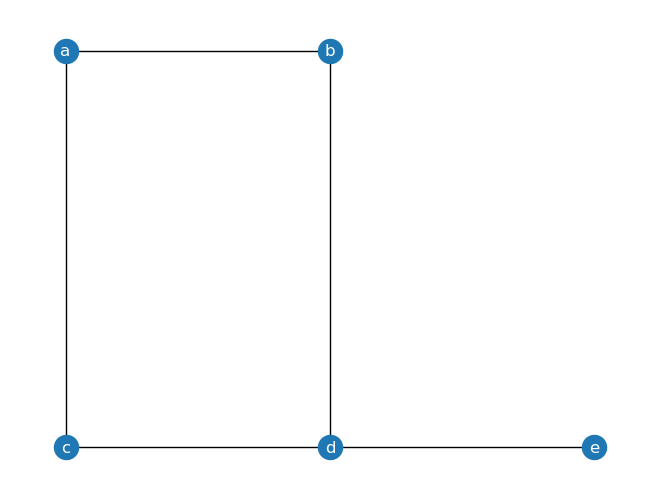

In [137]:
nx.draw(G, with_labels=True, pos=positions, font_color="white")

In [133]:
G.add_edge("a", "b", weight=1)
G.add_edge("a","c", weight=2)
G.add_edge("b","d", weight=1)
G.add_edge("c","d", weight=1)
G.add_edge("d","e", weight=3)

In [134]:
print(G.edges)
print(G.edges.data())

[('a', 'b'), ('a', 'c'), ('b', 'd'), ('c', 'd'), ('d', 'e')]
[('a', 'b', {'weight': 1}), ('a', 'c', {'weight': 2}), ('b', 'd', {'weight': 1}), ('c', 'd', {'weight': 1}), ('d', 'e', {'weight': 3})]


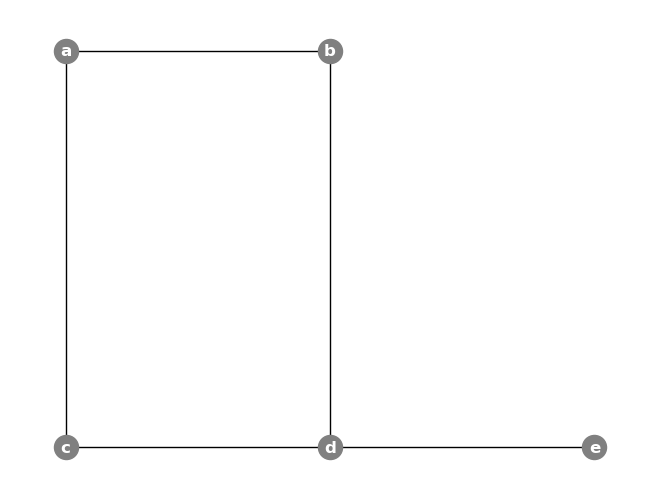

In [140]:
nx.draw(G, 
        pos=positions, 
        with_labels=True, 
        font_weight="bold", 
        font_color="white", 
        node_color="grey"
)

In [141]:
edge_labels = {(u, v): attrs["weight"] for u, v, attrs in G.edges.data()}

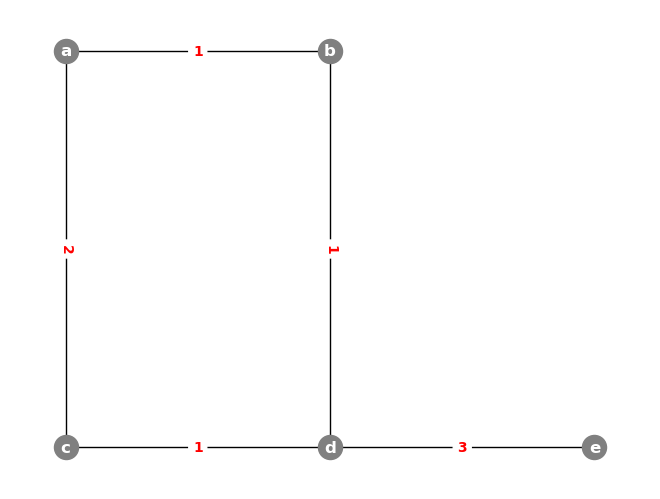

In [142]:
# Draw the graph
nx.draw(G, 
        pos=positions, 
        with_labels=True, 
        font_weight="bold", 
        font_color="white", 
        node_color="grey"
)

# Add edge labels
nx.draw_networkx_edge_labels(
    G, 
    positions,
    edge_labels=edge_labels,
    font_color='red', 
    font_weight="bold",
);

_**Figure 8.X.** A simple undirected graph consisting of five nodes and edges._

Although, you can easily add nodes and edges one at a time as shown previously, it is not typically very efficient way of construcing a graph. Luckily, `networkx` also allows you to pass the information for the graphs from a collection of items. Thus, we can create an identical graph as shown previously by passing a collection of nodes and edges to the graph as follows:

In [206]:
G2 = nx.Graph()

node_collection = [("a", {"coords": (0,5)}),
                   ("b", {"coords": (5,5)}),
                   ("c", {"coords": (0,0)}),
                   ("d", {"coords": (5,0)}),
                   ("e", {"coords": (10,0)}),
                  ]

edge_collection = [("a", "b", {"weight": 1}),
                   ("a", "c", {"weight": 2}),
                   ("b", "d", {"weight": 1}),
                   ("c", "d", {"weight": 1}),
                   ("d", "e", {"weight": 3}),
                  
                  ]

# Add nodes and edges from the collections
G2.add_nodes_from(node_collection)
G2.add_edges_from(edge_collection)

# Extract exact node locations
positions = {node: attrs["coords"] for node, attrs in G2.nodes.data()}

# Parse edge labels
edge_labels = {(u, v): attrs["weight"] for u, v, attrs in G2.edges.data()}

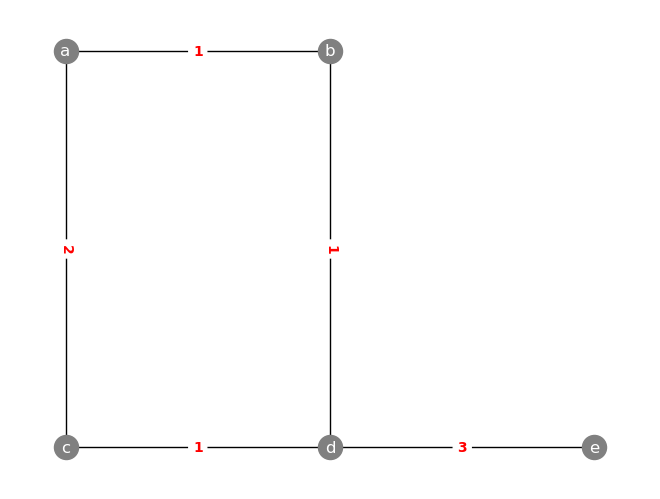

In [207]:
nx.draw(G2, 
        with_labels=True, 
        pos=positions, 
        font_color="white", 
        node_color="grey")

nx.draw_networkx_edge_labels(
    G2, 
    positions,
    edge_labels=edge_labels,
    font_color='red', 
    font_weight="bold",
);

In [208]:
distance, path = nx.single_source_dijkstra(G=G2, 
                                          source="a",
                                          target="e", 
                                          weight="weight", 
                                          )

In [209]:
print("Distance:", distance)
print("Path / visited nodes:", path)

Distance: 5
Path / visited nodes: ['a', 'b', 'd', 'e']


In [210]:
distance, path = nx.single_source_dijkstra(G=G2, 
                                          source="e",
                                          target="a", 
                                          weight="weight", 
                                          )

In [211]:
print("Distance:", distance)
print("Path / visited nodes:", path)

Distance: 5
Path / visited nodes: ['e', 'd', 'b', 'a']


In [212]:
path_edges = list(zip(path,path[1:]))
path_edges

[('e', 'd'), ('d', 'b'), ('b', 'a')]

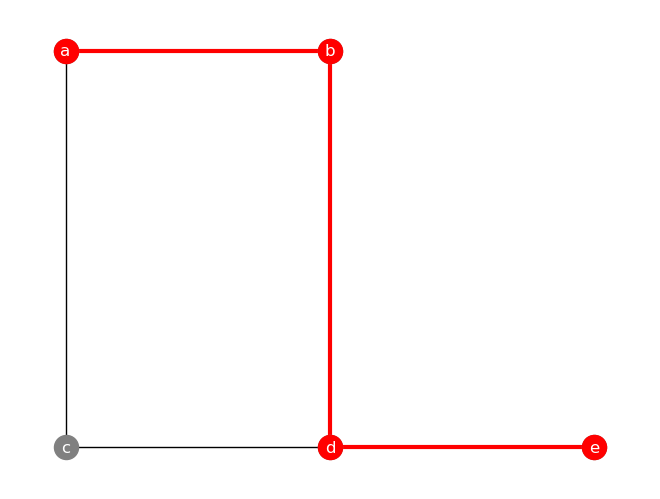

In [216]:
nx.draw(G2, 
        with_labels=True, 
        pos=positions, 
        font_color="white", 
        node_color="grey")

nx.draw_networkx_nodes(G2, positions, nodelist=path, node_color='r')
nx.draw_networkx_edges(G2, positions, edgelist=path_edges, edge_color='r', width=3);

### Directed graph

In [173]:
G_directed = nx.MultiDiGraph()

In [174]:
node_collection = [("a", {"coords": (0,5)}),
                   ("b", {"coords": (5,5)}),
                   ("c", {"coords": (0,0)}),
                   ("d", {"coords": (5,0)}),
                   ("e", {"coords": (10,0)}),
                  ]

In [176]:
edge_collection = [("a", "b", {"weight": 1, "color": "red"}),
                   # bidirectional a<->c
                   ("a", "c", {"weight": 2, "color": "green"}),
                   ("c", "a", {"weight": 2, "color": "green"}),
                   # bidirectional b<->d
                   ("b", "d", {"weight": 1, "color": "green"}),
                   ("d", "b", {"weight": 1, "color": "green"}),
                   
                   ("c", "d", {"weight": 1, "color": "red"}),
                   ("d", "e", {"weight": 3, "color": "red"}),
                  ]

In [181]:
# Add nodes and edges from the collections
G_directed.add_nodes_from(node_collection)
G_directed.add_edges_from(edge_collection)

# Extract exact node locations
positions = {node: attrs["coords"] for node, attrs in G_directed.nodes.data()}

# Parse edge labels
edge_labels = {(u, v): attrs["weight"] for u, v, attrs in G_directed.edges.data()}

# Parse edge colors
edge_colors = [attrs["color"] for u, v, attrs in G_directed.edges.data()]

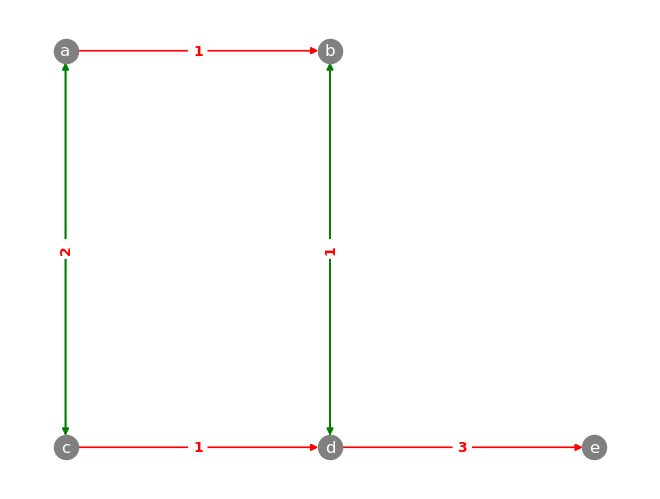

In [182]:
nx.draw(G_directed, 
        with_labels=True, 
        pos=positions, 
        font_color="white", 
        node_color="grey",
        edge_color=edge_colors
       )

nx.draw_networkx_edge_labels(
    G_directed, 
    positions,
    edge_labels=edge_labels,
    font_color='red', 
    font_weight="bold",
);

In [218]:
distance, path = nx.single_source_dijkstra(G=G_directed, 
                                          source="a",
                                          target="e", 
                                          weight="weight", 
                                          )

In [219]:
path_edges = list(zip(path,path[1:]))
path_edges

[('a', 'b'), ('b', 'd'), ('d', 'e')]

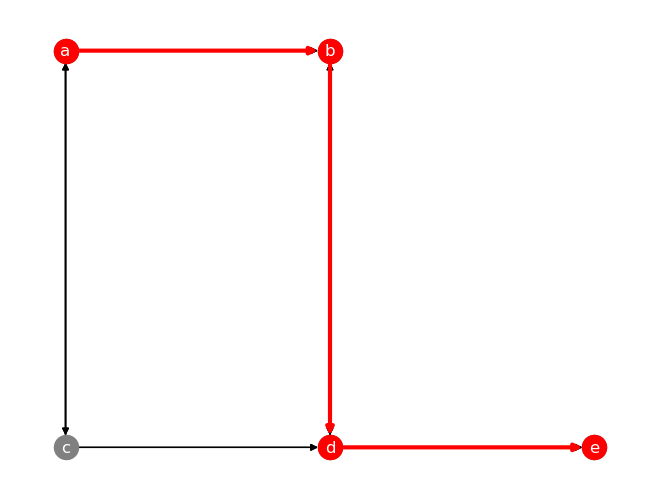

In [220]:
nx.draw(G_directed, 
        with_labels=True, 
        pos=positions, 
        font_color="white", 
        node_color="grey")

nx.draw_networkx_nodes(G_directed, positions, nodelist=path, node_color='r')
nx.draw_networkx_edges(G_directed, positions, edgelist=path_edges, edge_color='r', width=3);

#### Question 8.1

What is the path length and route from `e` to `a` using the directed graph? 

In [ ]:
# You can use this cell to enter your solution.

In [223]:
# Solution

# This is a trick question: Because our graph is directed
# and there is no way out from node 'e', there is no path nor length
# from e to a

# When searching for such a path, networkx raises an error

# Uncomment to test yourself
# distance, path = nx.single_source_dijkstra(G=G_directed, source="e", target="a", weight="weight")

## Creating a graph from LineStrings

Data was obtained from 

In [224]:
import geopandas as gpd
import momepy
from contextily import add_basemap